# Математическая магия градиентного спуска (дополнительный урок)

**ДИСКЛЕЙМЕР** это необязательный урок. Тут очень много формул, много Python и много математики. Посмотрите его для ознакомления, позапускайте код. Но если ничего непонятно - не расстраивайтесь! На усвоение курса этот модули никак не влияет.

"Маленькие шажки", которыми мы двигаемся к оптимальному решению в виде формулы, выглядят следующим образом:
$$
w^{k+1} = w^k - \eta\nabla L(w)
$$
Переменная $\eta$ в формуле - т.н. *шаг градиентного спуска*.

Где $\nabla L(w)$ - вектор градиента функции. Этот вектор обладает следующими свойствами:

* имеет размерность вектора параметров. Если два параметра $[w_1,w_0]$ - в векторе будет два элемента
* элемент градиента под номером $i$ - это частная производная (вспоминаем математику за 11 класс и [смотрим в Википедию](https://ru.wikipedia.org/wiki/Производная_функции ) ) функции потерь $L(y, w)$ по параметру $w_i$

Вектор антиградиента всегда направлен в сторону уменьшения функции - в этом и есть всё волшебство! Мы будем двигаться в сторону минимума функции ошибки, потому что знаем как туда попасть - надо следовать по антиградиенту.

На картинке одномерный случай. Синяя стрелка - градиент, красная - антиградиент. Видно, что если двигаться по вектору антиградиента, то свалимся в минимум функции за конечное число шагов
![grad_vector](https://248006.selcdn.ru/public/Data-science-3/img/grad_vector.png)

Алгоритм визуально выглядит довольно интуитивно - (1) у тебя есть вектор-стрелочка (2) шагай по стрелочке, пока не попадёшь на дно "оврага", который представляет собой целевую функцию . В трёхмерном случае оптимальное значение функции находится в центре концентрицеских эллипсов (эллипс - проекция трёхмерной фигуры функции потерь на плоскость):

![grad_descent](https://248006.selcdn.ru/public/Data-science-3/img/grad_descent_intuit.png)

Как туда добраться, двигаясь маленькими шажками?

1. Стартуем алгоритм в случайной начальной точке $x^0$  
1. Вычисляем направление антиградиента $-f'(x^0)$
1. Перемещаемся по направлению градиента в точку $x^1 = x^0 - \eta f'(x^0)$
1. Повторяем шаги (1-3) для попадания в точку $x^2$
1. $\ldots$
1. Profit! Достигли оптимальной точки $x^*$

Алгоритм выше - универсальный, он позволяет найти точку минимума любой функции $f(x)$. А как же нам найти минимум функции качества линейной регрессии $L$?

Чтобы реализовать алгоритм градиентного спуска, выпишем частные прозводные функции качества линейной регрессии $L$ для параметров $\overline{w} = [w_1,\ldots,w_m]$ в простейшем случае $n=1$, то есть для одного обучающего примера (одного наблюдения):
$$
\left\{
\begin{array}{cc}
\frac{\partial L}{\partial w_0} = 2\cdot(-1)\cdot1\cdot (y_1 - (w_0x_0^1 + \ldots+w_mx_m^1)) &\\
\frac{\partial L}{\partial w_k} = 2\cdot(-1)\cdot x_1^1 \cdot (y_1 - (w_0x_0^1 + \ldots+w_mx_m^1)) &  k\neq 0\\
\end{array}
\right.
$$

В формуле все обозначения вам известны

* $w_0, \ldots, w_m$ - коэффициенты линейной регрессиии $m$ - количество фичей
* $x_0, \ldots, x_m$ - фичи.

Эту формулу с частными производными можно легко обобщить на случай, когда в обучающей выборке не один объект, а $n$ - просто добавляем сумму по всем объектам от 1 до $n$:
$$
\left\{
\begin{array}{cc}
\frac{\partial L}{\partial w_0} = \frac{2}{n}\cdot(-1)\cdot \sum_{i=1}^{n} 1\cdot \left(y_i - \sum_{j=1}^{m}w_jx_j^i\right) &\\
\frac{\partial L}{\partial w_k} = \frac{2}{n}\cdot(-1)\cdot \sum_{i=1}^{n} x_k^i \cdot\left(y_i - \sum_{j=1}^{m}w_jx_j^i\right) & k\neq 0 \\
\end{array}
\right.
$$

Что значат переменные в этой формуле?
* $n$ - число точек в обучающей выборке
* $m$ - число фичей в датасете
* $k$ - номер коэффициента в списке параметров линейной регрессии $w = [w_0,\ldots,w_m]$
* $y_i$ - значение целевой переменной на объекте обучающей выборки под номером $i$
* $x_j^i$ - значение фичи под номером $j$ на объекте обучающей выборки под номером $i$


**ВНИМАНИЕ** я выписал эти формулы в тетрадке, потому что знаю, как искать производную. Это знание выходит за пределы курса. Слушателю не нужно знать, как они получаются, но если очень хочется - можно посмотреть видео на ютубе: https://www.youtube.com/watch?v=sDv4f4s2SB8

Алгоритм градиентного спуска следующий:

1. Вычислить градиент $\nabla L(w)$
1. Вычислить новый вектор  $w^{k+1} = w^k - \eta\nabla L(w)$
1. Повторять пункты до тех пор, пока $w^{k+1}$ и $w^{k}$ не сойдутся вместе, то есть вектор весов перестанет обновляться

Чтобы лучше понять этот метод, давайте реализуем его "с нуля" на языке Python

Загружаем датасет из приложенного csv

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('../3/3.10_non_linear.csv', sep=',')
data = data[(data.x_train > 1) & (data.x_train < 5)].copy()
data.head()

,x_train,y_train
5,1.182421,1.860341
6,1.251605,1.878928
7,1.270474,2.430015
8,1.402553,2.327856
9,1.427711,2.203649


Отображаем точки на графике

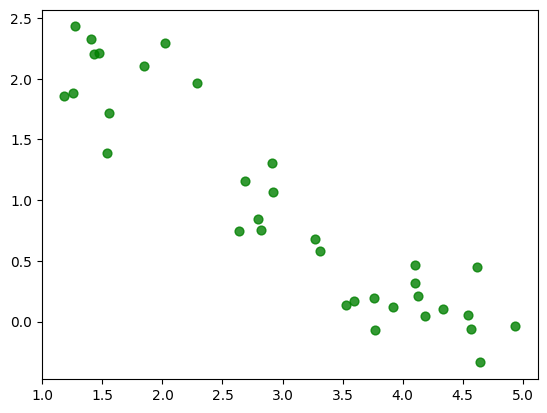

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

# основной график
plt.scatter(data.x_train, data.y_train, 40, 'g', 'o', alpha=0.8, label='data')
plt.show()

Реализуем метод градиентного спуска:

Вычисляем градиент

In [19]:
from scipy.spatial import distance
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def gradient(X, y, w) -> np.array:
    # количество обучающих примеров в выборке
    n = X.shape[0]
    # считаем прогноз
    y_hat = X.dot(w.T)
    # вычисляем ошибку прогноза
    # print(X.shape)
    # print(y.shape)
    # print(y_hat.shape)
    error = y - y_hat
    # print(error.shape)
    # print("==============")
    # дальше pointwise перемножение - умножаем каждую из координат на ошибку
    grad = np.multiply(X, error).sum(axis=0)*(-1.0)*2.0 / n
    return grad, error

Делаем шаг градиентного спуска

In [17]:
def eval_w_next(X, y, eta, w_current):
    # вычисляем градиент
    grad, error = gradient(X, y, w_current)
    # делаем шаг градиентного спуска
    w_next = w_current - eta*grad
    # проверяем условие сходимости
    # print(w_current)
    # print(w_next)
    # print(grad)
    # print(error)
    w_current = w_current[0]
    weight_evolution = distance.euclidean(w_current, w_next[0])
    return (w_next, weight_evolution, grad)

Повторяем шаги (1,2) до сходимости

In [5]:
def gradient_descent(X: np.array, y: np.array, eta=0.01, epsilon=0.001) -> np.array:
    m = X.shape[1] # количество фичей
    # инициализируем рандомом веса
    w = np.random.random(m).reshape(1, -1)
    w_next, weight_evolution, grad = eval_w_next(X, y, eta, w)
    step = 0
    # повторяем до сходимости вектора весов
    while weight_evolution > epsilon:
        w = w_next
        w_next, weight_evolution, grad = eval_w_next(X, y, eta, w)
        step += 1
        if step % 100 ==0:
            print("step %s |w-w_next|=%.5f, grad=%s" % (step, weight_evolution, grad))
    return w

Запускаем обучение

In [18]:
# трансформируем плоский массив X в вектор-столбец
X = data['x_train'].values.reshape(-1, 1)
n = X.shape[0]
# добавляем тривиальный признак w_0, столбец из единиц. См. прошлый урок, почему так
X = np.hstack([
    np.ones(n).reshape(-1,1),
    X
])
yy = data['y_train'].values.reshape(-1, 1)
# yy = data['y_train']
w = gradient_descent(X, yy, eta=0.008)

(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)
(34, 1)
(34, 1)
(34, 1)
(34, 2)


У нас произошло несколько сотен итераций, на каждой итерации мы:
* вычисляем вектор весов
* смотрим расстояние между новым вектором весов и векторов весов с предыдущего шага
* если изменения в векторе весов небольшие (скажем, четвёртый знак поcле запятой) - останавливаем итерации

Когда вектор перестаёт меняться - говорят, что алгоритм "сошёлся" (имеется в виду сходимость к оптимальной точке) - это значит, что итерации можно останавливать.

Применяем модель

In [20]:
support = np.linspace(X.min(), X.max(), num=100)
# делаем предикт - считаем предсказания модели в каждой точке обучающей выборки в виде y=X*w
y_hat = np.hstack([
    np.ones(support.size).reshape(-1, 1),
    support.reshape(-1, 1)
]).dot(w.T)

Визуализируем результаты

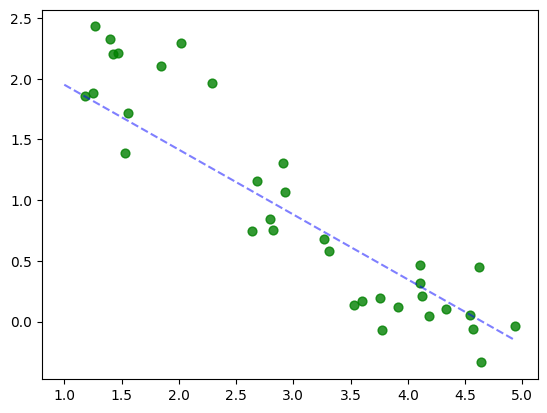

In [21]:
# строим график
plt.plot(support, y_hat, 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')
plt.show()

Готово! Мы построили модель линейной регрессии, обучив коэффициенты регрессии с помощью нового инструмента - градиентного спуска. В реальных задачах выписывать градиенты не всегда необходимо - для этих целей есть готовая реализация [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html). С понятием градиентного спуска вы очень плотно познакомитесь, когда будете изучать нейронные сети. Градиентный спуск - это основной метод для обучения нейросетей.

**Особенности градиентного спуска**

1. Нужно подбирать параметр $\eta$. Еcли выбрать параметр слишком малым, то обучение регрессии будет происходить слишком медленно. Если слишком большим - вычисления не сойдутся к оптимуму. Вариант решения - адаптивный выбор величины шага (запомните это словосочетание - не раз услышите его в курсе по нейросетям).
1. Долгие вычисления, если размер выборки $n$ становится большим. В этом случае мы можем вычислять градиент не по всей выборке за один шаг, а по одному случайному элементу выборки - в этом случае вычислений значительно меньше.

Кроме того, градиент можно считать не только по одному объекту, но и по случайной подвыборке (батчу). Такая модификация алгоритма называется градиентным спуском по мини-батчам.


Хорошая теория [тут](http://www.machinelearning.ru/wiki/images/6/68/voron-ML-Lin.pdf). Неплохая статья с разбором [формул обновления весов](https://medium.com/@lachlanmiller_52885/machine-learning-week-1-cost-function-gradient-descent-and-univariate-linear-regression-8f5fe69815fd). Видео от [специализации ШАД на coursera](https://ru.coursera.org/lecture/supervised-learning/gradiientnyi-spusk-dlia-linieinoi-rieghriessii-adARX)